## EDA

#### Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.shape

(7043, 21)

In [3]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

#### Dataset Feature Description

- **customerID**: Unique identifier for each customer.  
  *Not useful for prediction, but helps track records.*

- **gender**: Customer’s gender (`Male`/`Female`).  
  *May have minor influence; often not a strong predictor.*

- **SeniorCitizen**: Indicates if the customer is a senior (`1` = Yes, `0` = No).  
  *Seniors may have different churn patterns.*

- **Partner**: Whether the customer has a partner (`Yes`/`No`).  
  *Customers with partners may be less likely to churn.*

- **Dependents**: Whether the customer has dependents (`Yes`/`No`).  
  *Customers with dependents may be more stable.*

- **tenure**: Number of months the customer has stayed.  
  *Lower tenure often correlates with higher churn risk.*

- **PhoneService**: Whether the customer has phone service (`Yes`/`No`).  
  *Lack of service may increase churn.*

- **MultipleLines**: If the customer has multiple phone lines.  
  *More lines can indicate higher engagement, reducing churn.*

- **InternetService**: Type of internet service (`DSL`, `Fiber optic`, `None`).  
  *Service type can impact satisfaction and churn.*

- **OnlineSecurity**: If the customer has online security add-on.  
  *Add-ons may increase loyalty.*

- **OnlineBackup**: If the customer has online backup add-on.  
  *Similar to above.*

- **DeviceProtection**: If the customer has device protection add-on.  
  *Indicates engagement.*

- **TechSupport**: If the customer has tech support add-on.  
  *Access to support may reduce churn.*

- **StreamingTV**: If the customer has streaming TV service.  
  *More services can mean less churn.*

- **StreamingMovies**: If the customer has streaming movies service.  
  *Same as above.*

- **Contract**: Contract type (`Month-to-month`, `One year`, `Two year`).  
  *Longer contracts usually mean lower churn.*

- **PaperlessBilling**: Whether the customer uses paperless billing.  
  *May indicate tech-savviness or engagement.*

- **PaymentMethod**: How the customer pays (`Electronic check`, `Mailed check`, etc.).  
  *Some methods may correlate with churn.*

- **MonthlyCharges**: Amount charged monthly.  
  *High charges may increase churn if not matched by value.*

- **TotalCharges**: Total amount charged to the customer.  
  *Lower total charges may indicate new customers (higher churn risk).*

- **Churn**: **Target variable** (`Yes`/`No`).  
  *Indicates if the customer left the company.*


#### Replace invalid entries (' - ' or blank spaces) with NaN

In [ ]:
df = df.replace([' - ', ' ', ' -', '- '], np.nan)

numeric_cols = ['TotalCharges', 'MonthlyCharges', 'tenure']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [59]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [56]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6530
Churn                  2
dtype: int64

- `MonthlyCharges`, `TotalCharges`, `Tenure` needs to be scaled and normalized.
- Other Columns are categoricals so they will be encoded.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
import warnings
warnings.filterwarnings('ignore')

#### 1. Countplot of Churns 

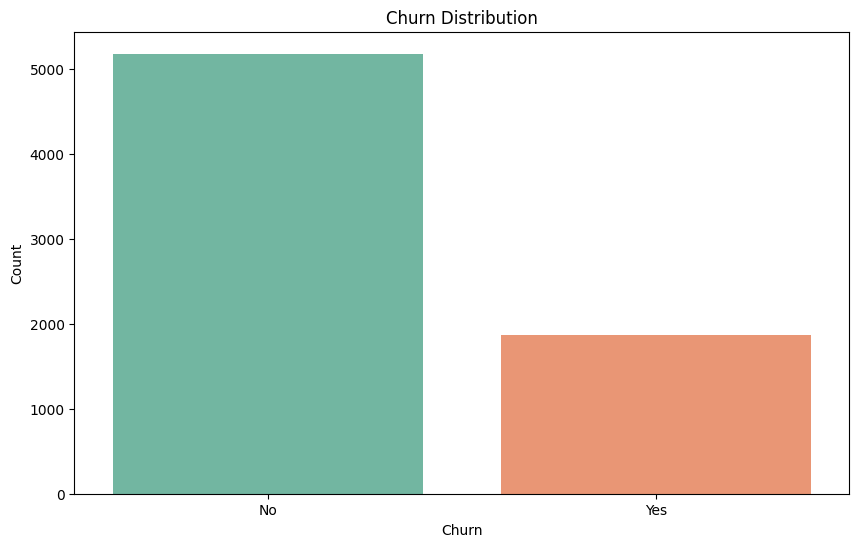

In [12]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

- Data is imbalanced.
- to balance it , sampling techniques will be used

#### 2. Relation between Categorical columns and Churn 

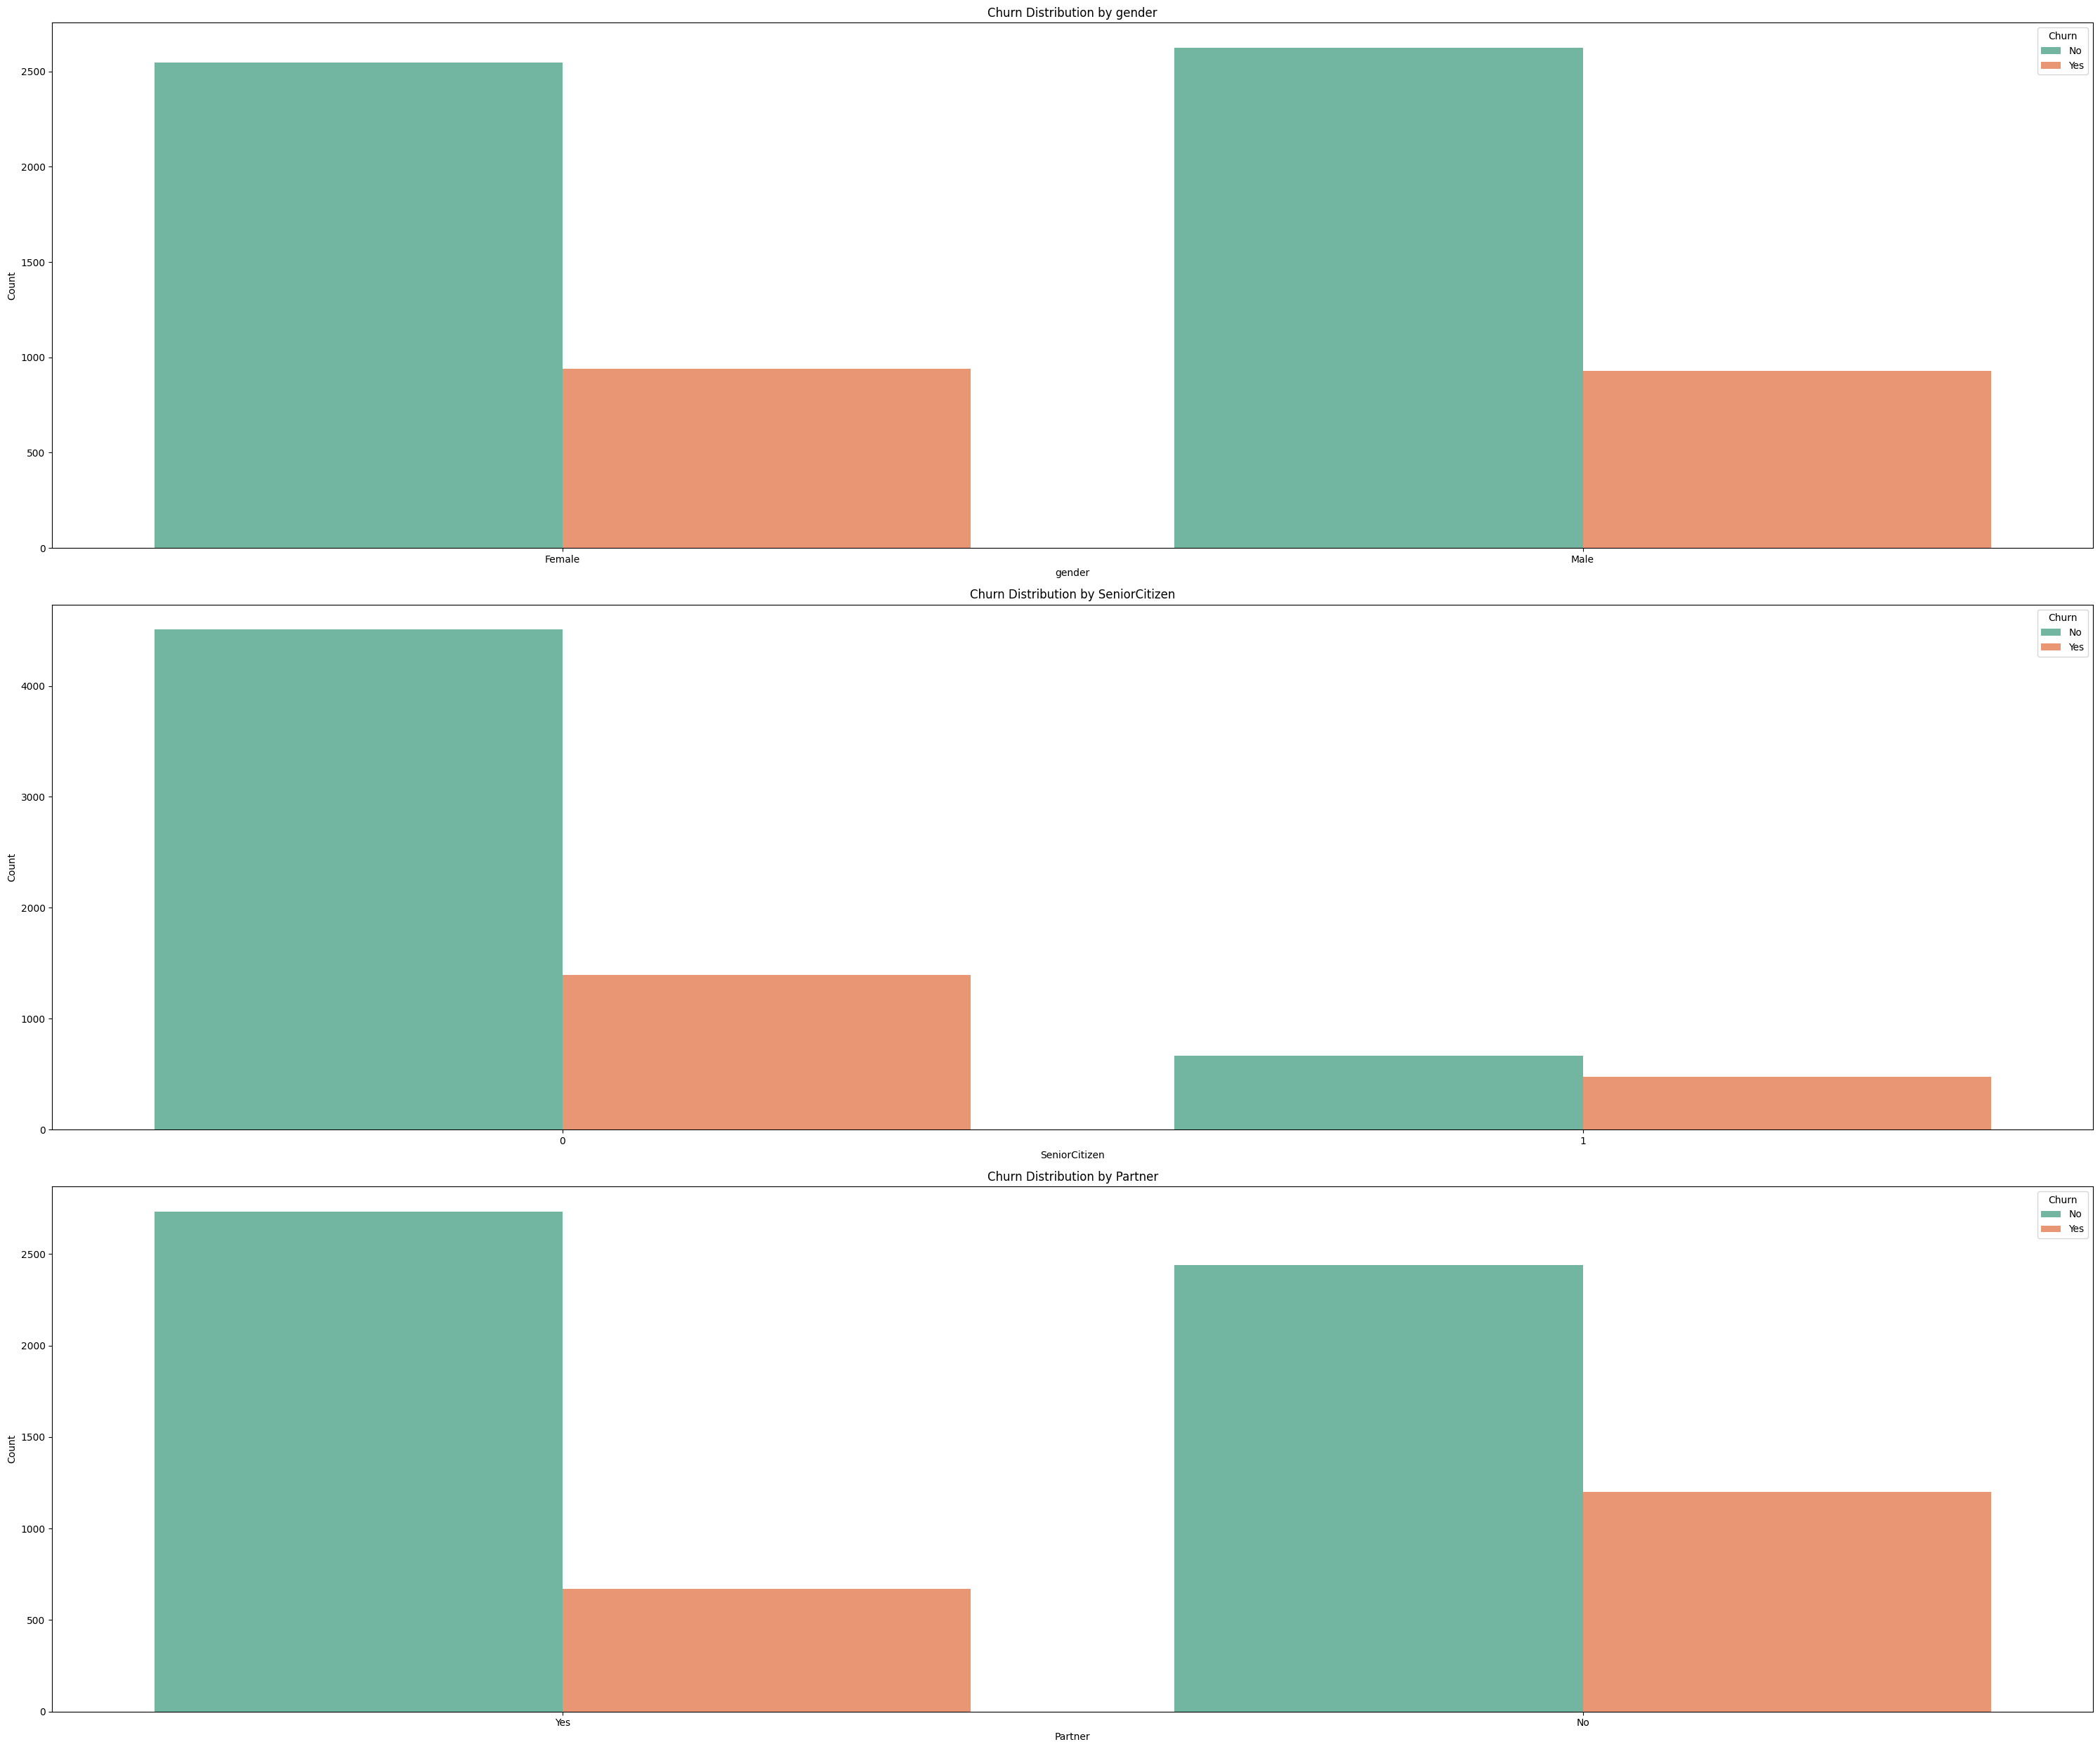

In [28]:
features = ['gender', 'SeniorCitizen', 'Partner']

plt.figure(figsize=(30, 25))
for i, feature in enumerate(features, 1):
    plt.subplot(3, 1, i)
    sns.countplot(data=df, x=feature, hue='Churn', palette='Set2')
    plt.title(f'Churn Distribution by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Conclusion:**

- The churn rate appears similar for both genders, indicating that gender does not have a significant impact on customer churn.
- Senior citizens show a higher tendency to churn compared to non-senior customers, suggesting age may influence churn behavior.
- Customers without partners are more likely to churn than those with partners, implying that having a partner may contribute to customer retention.

#### 3. Impact of categorical columns

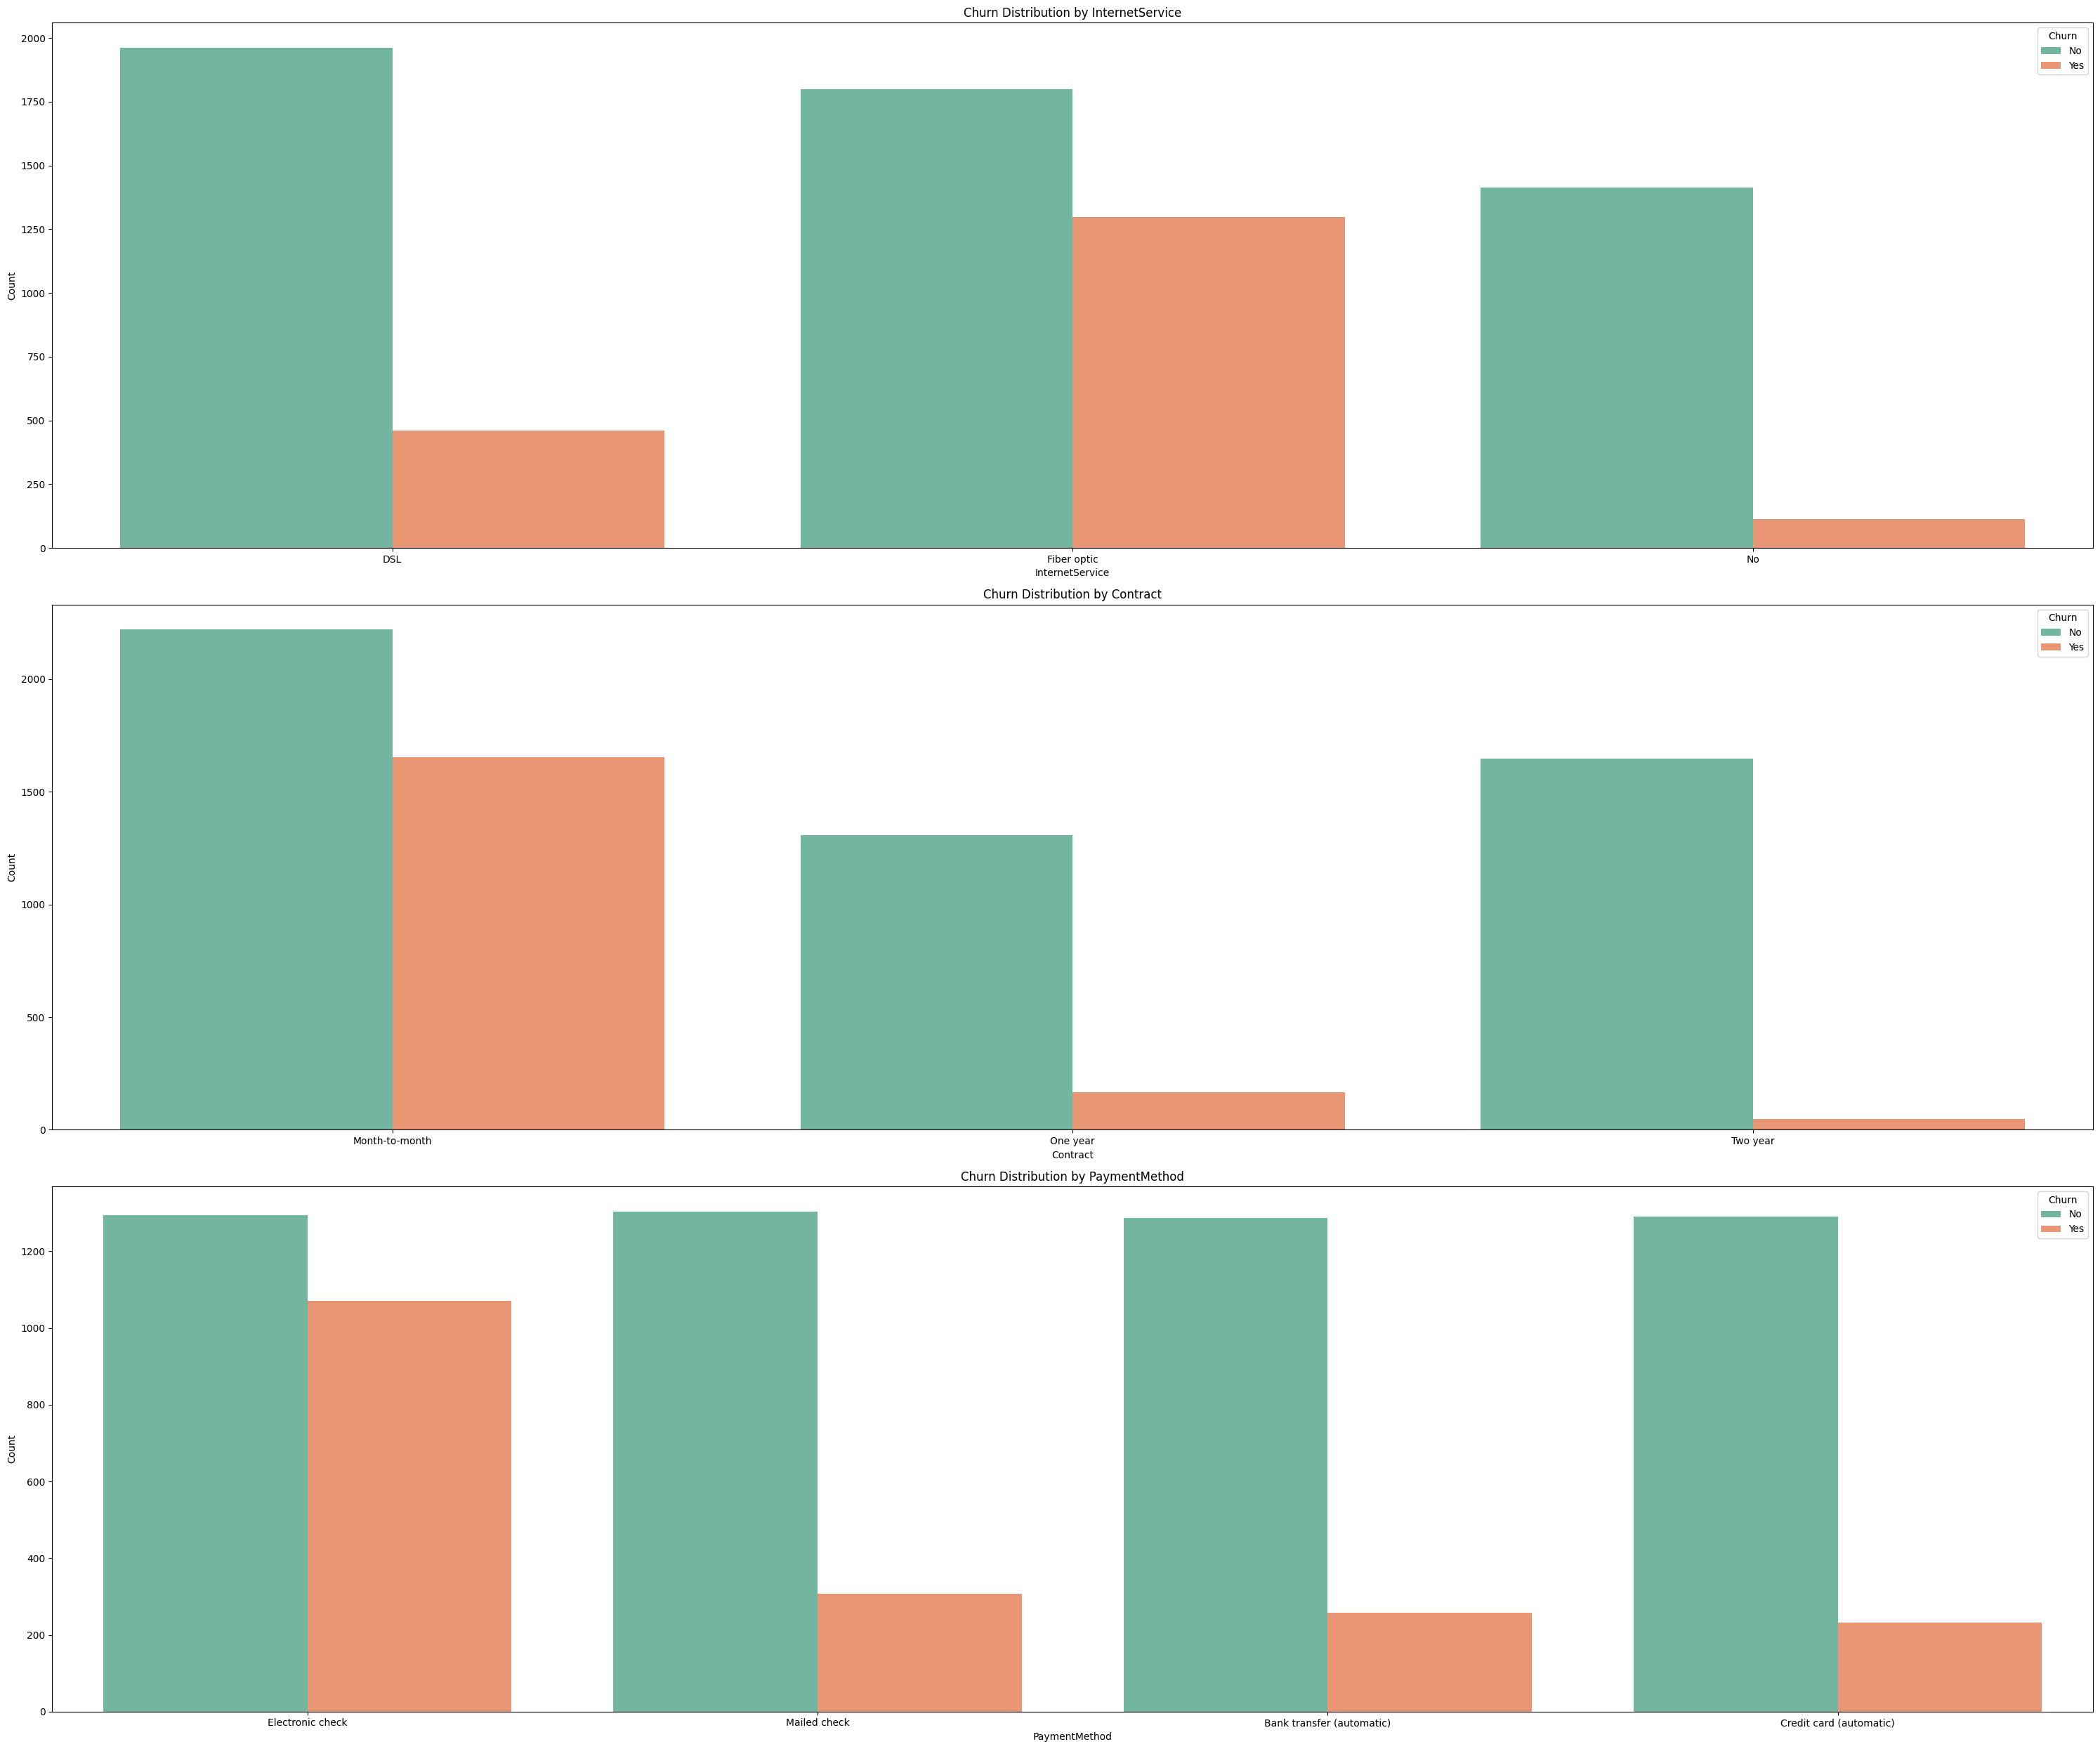

In [27]:
features = ['InternetService', 'Contract', 'PaymentMethod']
plt.figure(figsize=(30, 25))
for i, feature in enumerate(features, 1):
    plt.subplot(3, 1, i)
    sns.countplot(data=df, x=feature, hue='Churn', palette='Set2')
    plt.title(f'Churn Distribution by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Conclusion:**

- Customers with Fiber optic internet service have a higher churn rate compared to those with DSL or no internet service.
- Month-to-month contract customers are much more likely to churn than those with one-year or two-year contracts, highlighting the importance of contract type in retention.
- Customers who pay by electronic check show a higher tendency to churn compared to other payment methods, suggesting payment method is a relevant churn indicator.

#### 4. Numerical Column Distribution 

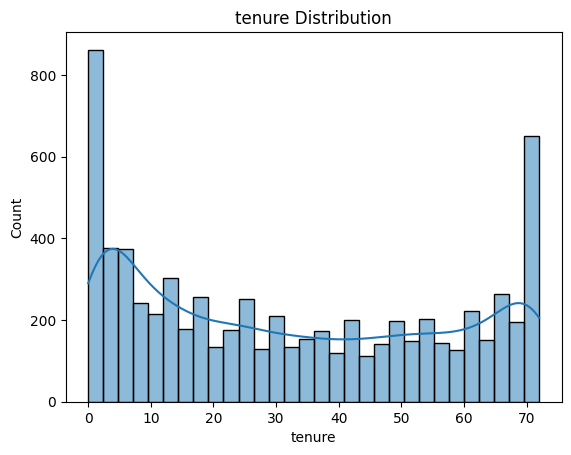

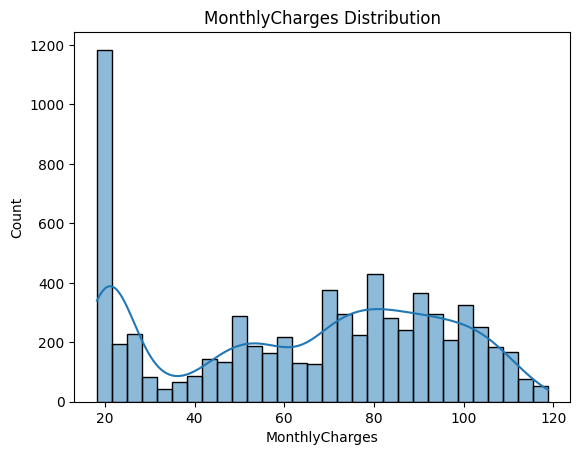

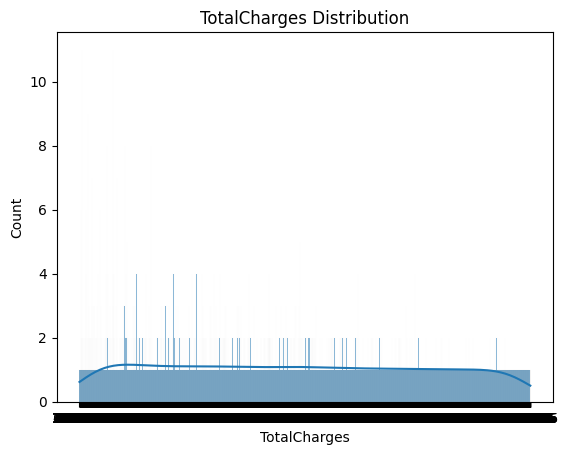

In [37]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for col in num_cols:
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

#### 5. Relationship between Numeric columns and Churn

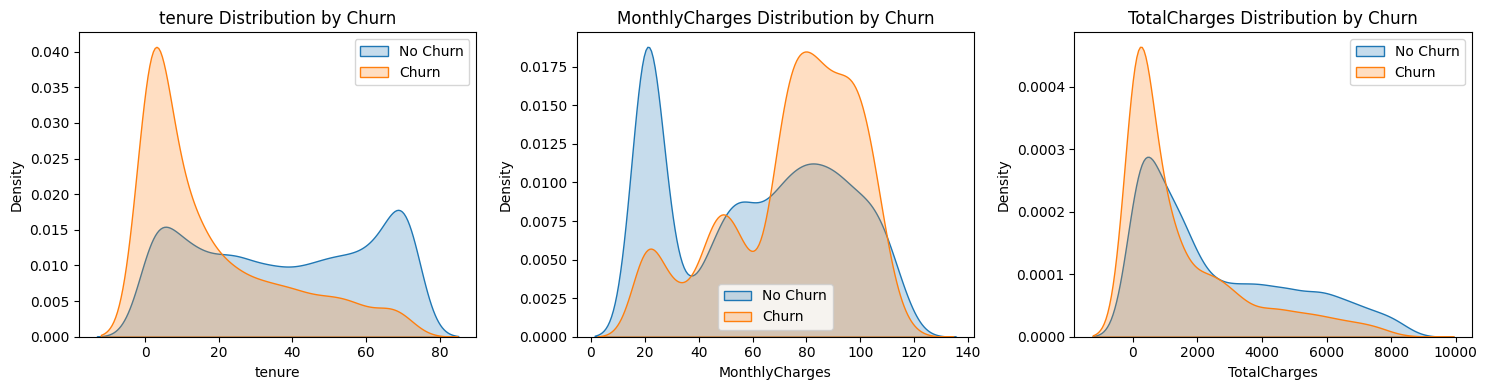

In [41]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(15, 4))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 3, i)
    # Convert to numeric, coerce errors to NaN, then drop NaN for KDE
    data_no = pd.to_numeric(df[df['Churn']=="No"][col], errors='coerce').dropna()
    data_yes = pd.to_numeric(df[df['Churn']=="Yes"][col], errors='coerce').dropna()
    sns.kdeplot(data_no, label='No Churn', fill=True)
    sns.kdeplot(data_yes, label='Churn', fill=True)
    plt.title(f'{col} Distribution by Churn')
    plt.legend()

plt.tight_layout()
plt.show()

**Conclusion:**

- Customers who churn tend to have shorter tenure, indicating that newer customers are more likely to leave.
- Churned customers generally have higher monthly charges, suggesting that higher costs may contribute to churn.
- Total charges for churned customers are lower on average, likely because they have been with the company for a shorter period.

These patterns highlight the importance of customer retention strategies for new and high-paying customers.

#### 6. BoxPlot to detect outliers

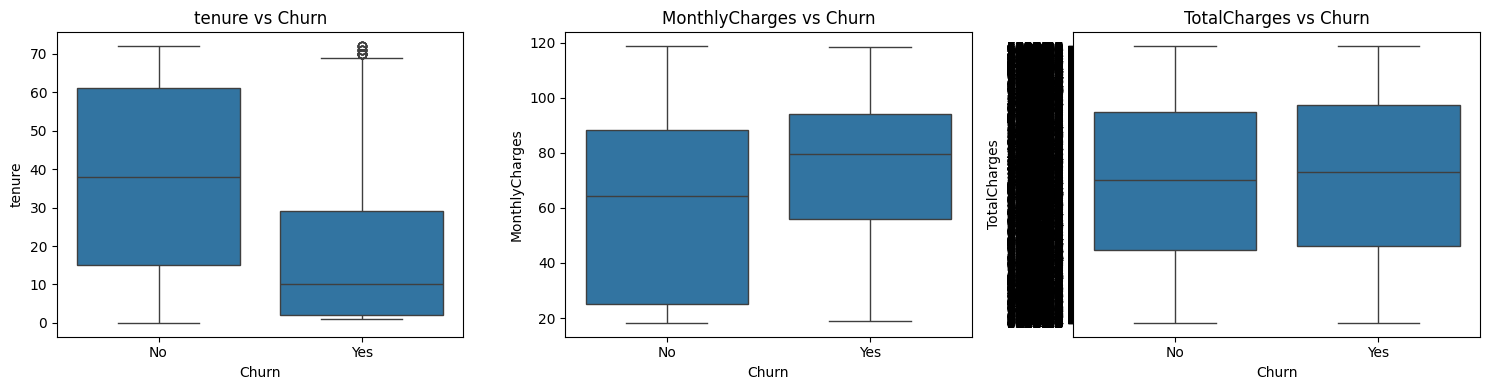

In [43]:
plt.figure(figsize=(15, 4))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x='Churn', y=col, data=df)
    plt.title(f'{col} vs Churn')

plt.tight_layout()
plt.show()

**Conclusion:**

- The boxplots show that customers who churn generally have lower tenure, confirming that newer customers are more likely to leave.
- Churned customers tend to have higher monthly charges, indicating that higher costs may be a factor in their decision to leave.
- Total charges are lower for churned customers, which is consistent with their shorter tenure.


#### 7. Correlation between numeric values

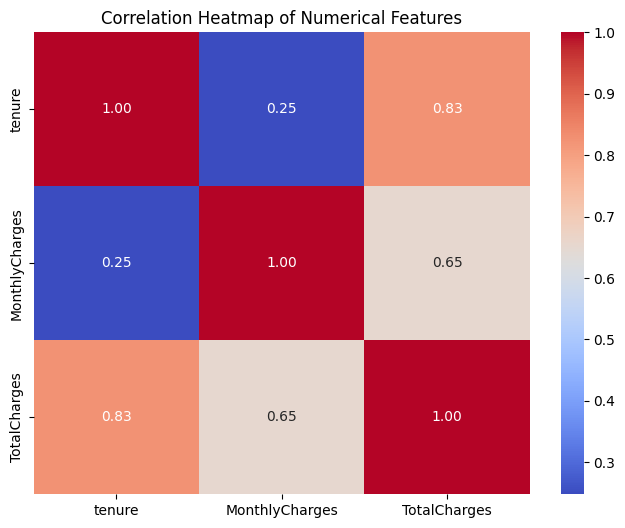

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['tenure'] = pd.to_numeric(df['tenure'], errors='coerce')
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
plt.figure(figsize=(8,6))
corr = df[['tenure','MonthlyCharges','TotalCharges']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

**Conclusion:**

- These relationships highlight that while tenure and total charges are closely linked, monthly charges provide unique information for churn analysis.

#### 8. Pair Plot 

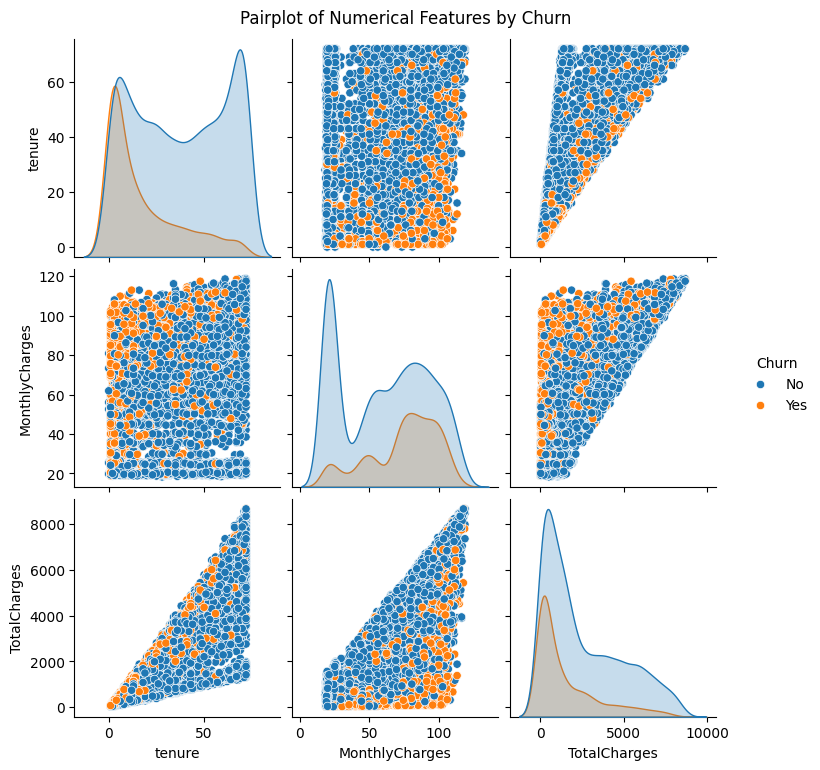

In [48]:
sns.pairplot(df[['tenure','MonthlyCharges','TotalCharges','Churn']], hue='Churn', diag_kind='kde')
plt.suptitle("Pairplot of Numerical Features by Churn", y=1.02)
plt.show()

**Conclusion:**

- The pairplot reveals that customers who churn are concentrated in the lower tenure and lower total charges regions, indicating they tend to leave earlier in their customer lifecycle.
- There is a strong positive relationship between tenure and total charges, as expected, since longer tenure leads to higher accumulated charges.
- Monthly charges do not show a strong separation between churned and non-churned customers, but higher monthly charges are slightly more common among those who churn.
- Overall, tenure and total charges are strong indicators of churn, while monthly charges provide additional but less distinct information.

#### 9. Chur Rate by Contract and InternetService

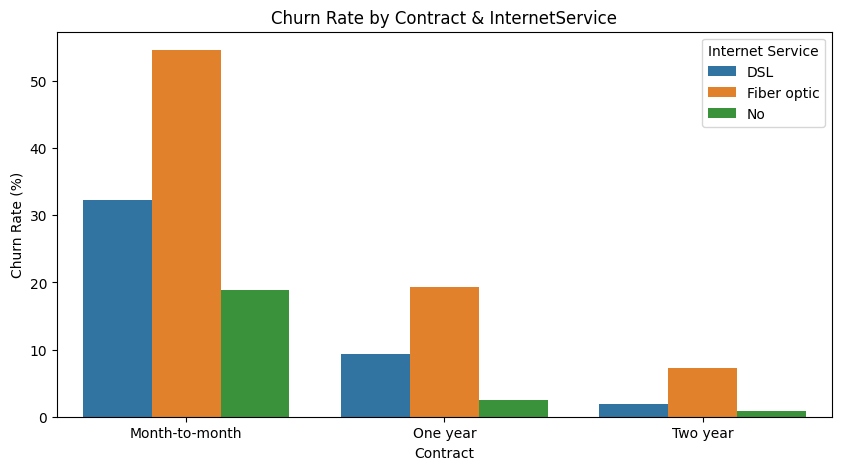

In [49]:
grouped = df.groupby(['Contract', 'InternetService'])['Churn'].value_counts(normalize=True).mul(100).rename('ChurnRate').reset_index()
plt.figure(figsize=(10,5))
sns.barplot(x='Contract', y='ChurnRate', hue='InternetService', data=grouped[grouped['Churn']=='Yes'])
plt.title("Churn Rate by Contract & InternetService")
plt.ylabel("Churn Rate (%)")
plt.legend(title="Internet Service")
plt.show()

**Conclusion:**

- This highlights the importance of contract type and internet service in predicting and managing customer churn.

#### 10. Churn Relationship on Tenure

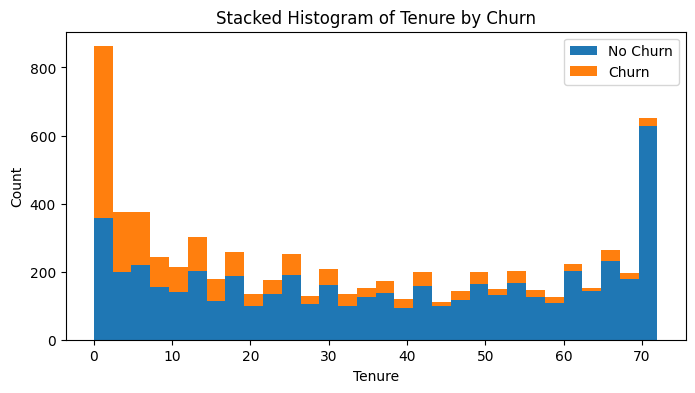

In [52]:
plt.figure(figsize=(8,4))
plt.hist([df[df['Churn']=='No']['tenure'], df[df['Churn']=='Yes']['tenure']], 
         bins=30, stacked=True, label=['No Churn','Churn'])
plt.title("Stacked Histogram of Tenure by Churn")
plt.xlabel("Tenure")
plt.ylabel("Count")
plt.legend()
plt.show()

**Conclusion**
- It confirms that lower Tenure leads to higher churn rate.